##AI-Powered Personal Finance Assistant for College Students
Course: Fundamentals of MIS | SDG: Goal 10 — Reduced Inequalities

In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY').strip())
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [ ]:
!pip install -q google-generativeai Pillow

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

# Retrieve the API key and strip any leading/trailing whitespace
api_key = userdata.get('GEMINI_API_KEY')
if api_key:
    api_key = api_key.strip()

# Configure with the new google.genai package (if available and preferred), otherwise stick to the original.
# For now, let's keep it as is, but ensure the package is correctly initialized.
# The error indicates a credential issue, not necessarily the package name itself yet.
# Let's ensure genai.configure is called correctly with the retrieved key.
genai.configure(api_key=api_key)
print("Gemini initialized successfully.")

Gemini initialized successfully.


#Section 1: Problem and Population (text cell)

---



One paragraph. Persona, failure point, SDG. Note anything that changed since M1 and why.

My project focuses on SDG 15: Life on Land. The problem is that San Jose parks and creek trails can have issues like illegal dumping, invasive plants, damaged trees, blocked trails, and erosion. These problems harm native plants, wildlife habitat, and public green spaces. The specific person affected is a San Jose park volunteer who notices these problems during a cleanup or trail walk. The failure point is that the volunteer may not know the right category, urgency level, environmental impact, or action needed. Since Milestone 1, the idea stayed mostly the same, but the system is now more focused on helping volunteers turn text reports and photos into clearer park maintenance reports.

#Section 2: Proposed System (text cell)

---



Input -> AI processing -> output -> real-world action. Diagram or structured description.



Input -> AI Processing -> Output -> Real-World Action

Input: A park volunteer submits a written report or uploads a photo of a park issue.

AI Processing:
The AI reads the written report or analyzes the image. It identifies the location, issue type, urgency level, environmental impact, and recommended action.

Output:
The system creates a clear report for park staff. The report includes the problem, possible risk, urgency, and suggested next step.

Real-World Action:
Park staff or trained volunteers review the AI output. If the report is accurate, they send it to the right department or schedule cleanup, trail repair, tree assessment, invasive plant removal, or erosion control.

#Section 3:  Project Code (code + text cells)

---



Select at least two labs that best support your system and modify to your project. For each: include the code cell, preserve the output, and explain in a text cell what it demonstrates about your system. The selection and explanation are the work. You are encouraged to use AI to help you debug your code.



## Lab 2: Structured Data Extraction


In [ ]:
schema_prompt = """
Extract information from this park habitat report from a volunteer.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (specific location in the park or trail, e.g., "Happy Hollow Park near the playground"),
  "issue_type": string (the type of problem described, e.g., "illegal dumping", "invasive plants", "damaged tree", "blocked trail", "trail erosion"),
  "urgency_level": "LOW" or "MEDIUM" or "HIGH",
  "environmental_impact": string (e.g., "minimal", "moderate", "significant ecosystem damage", "water quality risk", "habitat disruption"),
  "recommended_action": string (e.g., "clear debris", "remove invasive species", "tree assessment", "trail repair", "erosion control")
}
Urgency guide: LOW = minor cosmetic issue or localized inconvenience, MEDIUM = moderate impact requiring attention, HIGH = immediate threat to safety or ecosystem.
No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return exactly these five fields:")
for field in ["location", "issue_type", "urgency_level", "environmental_impact", "recommended_action"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these five fields:
  - location
  - issue_type
  - urgency_level
  - environmental_impact
  - recommended_action


In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY').strip())

resident_message = (
    "There's a significant amount of trash, including old tires and plastic bottles, "
    "dumped along the creek bank in Happy Hollow Park near the playground."
)

# The schema — the form the AI must fill in exactly.
schema_prompt = """
Extract information from this park habitat report from a volunteer.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (specific location in the park or trail, e.g., "Happy Hollow Park near the playground"),
  "issue_type": string (the type of problem described, e.g., "illegal dumping", "invasive plants", "damaged tree", "blocked trail", "trail erosion"),
  "urgency_level": "LOW" or "MEDIUM" or "HIGH",
  "environmental_impact": string (e.g., "minimal", "moderate", "significant ecosystem damage", "water quality risk", "habitat disruption"),
  "recommended_action": string (e.g., "clear debris", "remove invasive species", "tree assessment", "trail repair", "erosion control")
}
Urgency guide: LOW = minor cosmetic issue or localized inconvenience, MEDIUM = moderate impact requiring attention, HIGH = immediate threat to safety or ecosystem.
No explanation. No markdown. JSON only.
"""

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
There's a significant amount of trash, including old tires and plastic bottles, dumped along the creek bank in Happy Hollow Park near the playground.

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "location": "Happy Hollow Park near the playground along the creek bank",
  "issue_type": "illegal dumping",
  "urgency_level": "MEDIUM",
  "environmental_impact": "water quality risk",
  "recommended_action": "clear debris"
}

Run 2:
{
  "location": "Happy Hollow Park near the playground along the creek bank",
  "issue_type": "illegal dumping",
  "urgency_level": "HIGH",
  "environmental_impact": "water quality risk",
  "recommended_action": "clear debris"
}

Run 3:
{
  "location": "Happy Hollow Park near the playground",
  "issue_type": "illegal dumping",
  "urgency_level": "HIGH",
  "environmental_impact": "water quality risk",
  "recommended_action": "clear debris"
}


In [ ]:
test_messages = [
    {
        "label": "Invasive Plants",
        "message": "I noticed a large patch of a fast-growing vine, possibly kudzu, choking out native shrubs along the path near the visitor center in Alum Rock Park."
    },
    {
        "label": "Blocked Trail (Spanish)",
        "message": "El sendero en el Parque del Río Guadalupe está bloqueado por un árbol caído. Es imposible pasar con una bicicleta o silla de ruedas."
    },
    {
        "label": "Severe Erosion",
        "message": "There's severe erosion creating a deep gully on the steep section of the Hidden Valley Trail, especially after the recent rains. It's becoming dangerous to hike."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()


=== Invasive Plants ===
Input: I noticed a large patch of a fast-growing vine, possibly kudzu, choking out native shrubs along the path near the visitor center in Alum Rock Park.
Output:
{
  "location": "Alum Rock Park near the visitor center along the path",
  "issue_type": "invasive plants",
  "urgency_level": "HIGH",
  "environmental_impact": "significant ecosystem damage",
  "recommended_action": "remove invasive species"
}

=== Blocked Trail (Spanish) ===
Input: El sendero en el Parque del Río Guadalupe está bloqueado por un árbol caído. Es imposible pasar con una bicicleta o silla de ruedas.
Output:
{
  "location": "Parque del Río Guadalupe",
  "issue_type": "blocked trail",
  "urgency_level": "HIGH",
  "environmental_impact": "habitat disruption",
  "recommended_action": "clear debris"
}

=== Severe Erosion ===
Input: There's severe erosion creating a deep gully on the steep section of the Hidden Valley Trail, especially after the recent rains. It's becoming dangerous to hike.
O

These outputs show that the AI can take different park reports and turn them into the same organized format each time. For example, it identified invasive plants as a high urgency issue and recommended removing invasive species. It also identified a blocked trail and recommended clearing debris. This helps park staff understand the report faster because the information is already sorted into clear fields.

The main thing Lab 2 demonstrates is consistency. Instead of giving a different style of answer each time, the AI follows the same structure: location, issue type, urgency level, environmental impact, and recommended action. This makes the report easier to review and easier to send to the right person.

## Lab 3: Visual Recognition

Saving SJM-L-SJBLIGHT-1031-3.webp to SJM-L-SJBLIGHT-1031-3.webp
Uploaded: SJM-L-SJBLIGHT-1031-3.webp
Displayed image size: 640x431 pixels


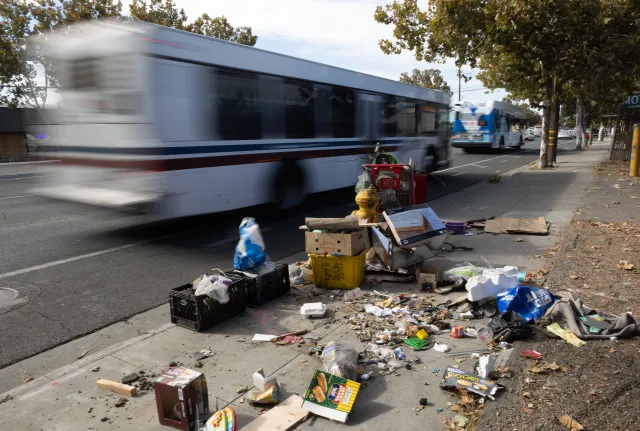

In [1]:
from google.colab import files
from PIL import Image as PILImage # Ensure PILImage is defined locally if this cell is run independently

# Upload your image from your computer.
uploaded = files.upload()

image_filename = None # Initialize image_filename

if uploaded:
    # Get the filename of the uploaded file.
    image_filename = list(uploaded.keys())[0]

    # Display the uploaded image so you can see what the model will analyze.
    img = PILImage.open(image_filename)

    # Add image resizing to prevent very large images from being displayed
    max_long_edge = 1024  # Define a max dimension for the longer edge
    width, height = img.size
    if max(width, height) > max_long_edge:
        if width > height:
            new_width = max_long_edge
            new_height = int(max_long_edge * height / width)
        else:
            new_height = max_long_edge
            new_width = int(max_long_edge * width / height)
        img = img.resize((new_width, new_height), PILImage.LANCZOS)
        print(f"Resized image for display to {new_width}x{new_height} pixels.")

    print(f"Uploaded: {image_filename}")
    print(f"Displayed image size: {img.size[0]}x{img.size[1]} pixels")
    display(img)
else:
    print("No file was uploaded.")
    print("Please upload an image in Part 1 to proceed with the analysis in Parts 3 and 6.")

In [11]:
import google.generativeai as genai
from PIL import Image as PILImage
import time
from google.colab import userdata # Added to ensure userdata is available for key retrieval

def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    # Retrieve the API key directly within the function for robustness
    api_key_local = userdata.get('GEMINI_API_KEY')
    if not api_key_local:
        raise ValueError("API Key is not configured. Please ensure GEMINI_API_KEY is set in Colab secrets and 'Notebook access' is ON.")
    api_key_local = api_key_local.strip() # Ensure no whitespace

    # Configure genai with the local API key before instantiating the model
    genai.configure(api_key=api_key_local)

    # Instantiate the model. The API key is now globally configured, so no need to pass it here.
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)

    # Add image resizing to prevent very large images from causing timeouts
    max_long_edge = 1024  # Define a max dimension for the longer edge
    width, height = img.size
    if max(width, height) > max_long_edge:
        if width > height:
            new_width = max_long_edge
            new_height = int(max_long_edge * height / width)
        else:
            new_height = max_long_edge
            new_width = int(max_long_edge * width / height)
        img = img.resize((new_width, new_height), PILImage.LANCZOS)
        print(f"Resized image to {new_width}x{new_height} for faster processing.")

    # Increase the timeout for generate_content to avoid ReadTimeout errors
    response = m.generate_content([question, img], request_options={'timeout': 600})
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


In [16]:
civic_questions = [
    ("PROBLEM",  "Describe the civic or environmental problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Rate the urgency of this situation as LOW, MEDIUM, or HIGH. Explain your rating in 2–3 sentences."),
    ("ACTION", "Which specific city department or service should respond to this? What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

# Add checks for image_filename and analyze_image function
if 'image_filename' not in locals() or image_filename is None:
    print("Error: No image has been uploaded. Please upload an image in Part 1 to proceed.")
elif 'analyze_image' not in globals():
    print("Error: The 'analyze_image' function is not defined. Please run the cell 'Part 2: Core Analysis Function' first.")
else:
    for label, question in civic_questions:
        print(f"--- {label} ---")
        answer, usage = analyze_image(image_filename, question)
        civic_results["answers"][label] = answer
        civic_results["total_tokens"] += usage.total_token_count
        print(answer)
        print()

    print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
    print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The image clearly depicts a significant civic and environmental problem centered around **waste accumulation, public sanitation, and the visible signs of homelessness.**

Here's a breakdown of what is specifically visible:

1.  **Massive Litter and Debris:** The entire foreground and mid-ground of the sidewalk and the adjacent dirt strip are covered in a diverse array of trash. This includes:
    *   Numerous food wrappers and packaging (e.g., a Snickers bar wrapper, other food boxes/bags).
    *   Plastic containers and bottles (e.g., a blue Bud Light container, other plastic bottles).
    *   Styrofoam packaging.
    *   Cardboard boxes, some broken down, others appearing to be used for storage.
    *   Plastic bags, some empty, some containing unknown contents.
    *   Scraps of paper, general refuse, and dirt/grime.
    *   What appears to be a discarded blanket or piece of fabric.
    *   Wooden scraps and other miscellaneous items.

2.  **Obstruction of Public Spa

In [ ]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: "Is there any graffiti or vandalism visible in this image?"
Resized image to 1024x768 for faster processing.

--- Response ---
No, there does not appear to be any graffiti visible in this image.

Regarding vandalism, while the area is heavily littered with discarded items and debris, which constitutes illegal dumping and defacement of the environment, there isn't clear evidence of deliberate destruction or damage to specific structures or property in the traditional sense of vandalism (e.g., broken windows, spray-painted walls, damaged signs). The scene is primarily one of extreme littering and accumulation of discarded belongings.

Tokens used: 1519


This Lab 3 output shows how image recognition supports my AI Park Habitat Report Assistant. The input is a photo of a park or outdoor area with a large amount of trash and discarded items. The AI analyzes the image and identifies the problem as illegal dumping or unmanaged waste. It also explains the possible impacts, such as habitat damage, public health risks, blocked space, and harm to the local environment.

This connects to my project because a San Jose park volunteer could upload a photo instead of trying to explain everything in writing. The AI helps describe the problem, rate the urgency, and suggest what city service or park staff should do next. This makes the report clearer and easier for staff to review.

#Section 4 — Edge Case Elicitation (code + text cells)

---



Design and run a prompt intended to surface a failure in your system. Target one of: an input the system wasn't designed for, a user outside the assumed majority, or a condition that makes the AI's confidence misleading. Preserve the output. In a text cell, document the prompt, the output, and a one-sentence assessment: failure, near-miss, or acceptable.



In [ ]:
edge_case_message = (
    "I'm having a really bad day. My cat knocked over my coffee and now my laptop isn't working. What should I do?"
)

print("--- Edge Case Message ---")
print(edge_case_message)
print("\n--- Structured extraction for edge case ---")

try:
    edge_case_result = extract_structured(edge_case_message)
    print(json.dumps(edge_case_result, indent=2, ensure_ascii=False))
except json.JSONDecodeError as e:
    print(f"JSON Decode Error: {e}")
    print("Raw response text could not be parsed into JSON. This indicates a potential failure.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Edge Case Message ---
I'm having a really bad day. My cat knocked over my coffee and now my laptop isn't working. What should I do?

--- Structured extraction for edge case ---
{
  "location": "N/A",
  "issue_type": "N/A",
  "urgency_level": "LOW",
  "environmental_impact": "N/A",
  "recommended_action": "N/A"
}


The prompt was: “I'm having a really bad day. My cat knocked over my coffee and now my laptop isn't working. What should I do?”

The output shows that the AI recognized the message was not related to a park habitat report. It returned “Not applicable,” “LOW” urgency, and “No action related to park habitat required.”

Assessment: Acceptable. The system handled an unrelated input correctly because it did not create a fake park issue or recommend unnecessary action. This shows the system can reject some inputs outside its designed purpose.